# Quora Duplicate Question Detection — Word2Vec + RF baseline, then RNN/LSTM



1. Clean and tokenize text
2. Train a **Word2Vec** model on the question corpus, average word vectors into a fixed-size
   question vector
3. Add a few simple hand-crafted text stats as extra features
4. Baseline: **Random Forest** on the vectorized features
5. Deep learning: concatenate both questions into a single string, tokenize, and feed through a
   **SimpleRNN**, then a **Bidirectional LSTM**
6. Compare results, then run inference on new question pairs




## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download("stopwords")
!pip install gensim imbalanced-learn textblob
import gensim
from gensim.utils import simple_preprocess

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score


from imblearn.over_sampling import SMOTE, RandomOverSampler


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.6 MB/s eta 0:00:00


## 2. Load Data

Using the full dataset here (not a small sample) — more data helps both the Word2Vec model and
the deep learning model generalize better.


In [ ]:
data = pd.read_csv("train.csv")
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)
print(data.shape)
data.head()


(404287, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [ ]:
data["is_duplicate"].value_counts(normalize=True)


,proportion
is_duplicate,
0,0.630799
1,0.369201


## 3. Text Cleaning

Same cleaning steps :
1. Lowercase
2. Tokenize
3. Remove punctuation
4. Remove stopwords
5. Stem each word (e.g. "running" → "run")

`simple_preprocess` from gensim handles lowercasing, tokenizing, and punctuation removal in one
call. We then remove stopwords and stem on top of that.


In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    tokens = simple_preprocess(text)  # lowercase, tokenize, strip punctuation
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return tokens

# This takes a few minutes on the full dataset — tqdm shows progress
tqdm.pandas()
data["q1_clean"] = data["question1"].progress_apply(clean_text)
data["q2_clean"] = data["question2"].progress_apply(clean_text)

data[["question1", "q1_clean"]].head()


100%|██████████| 404287/404287 [00:41<00:00, 9642.96it/s] 


,question1,q1_clean
0,What is the step by step guide to invest in sh...,"[step, step, guid, invest, share, market, india]"
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,"[stori, kohinoor, koh, noor, diamond]"
2,How can I increase the speed of my internet co...,"[increas, speed, internet, connect, use, vpn]"
3,Why am I mentally very lonely? How can I solve...,"[mental, lone, solv]"
4,"Which one dissolve in water quikly sugar, salt...","[one, dissolv, water, quikli, sugar, salt, met..."


## 4. Split Train / Test




In [ ]:
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=42, stratify=data["is_duplicate"]
)

train_df = data.loc[train_idx].reset_index(drop=True)
test_df = data.loc[test_idx].reset_index(drop=True)

print("Train:", train_df.shape, " Test:", test_df.shape)


Train: (323429, 8)  Test: (80858, 8)


## 5. Train Word2Vec on the Corpus

Word2Vec learns a dense vector for each word based on which words tend to appear near each other.
Training it on the full corpus (train + test question text, unsupervised, no labels involved) is
standard practice and does not leak label information.


In [ ]:
corpus = train_df["q1_clean"].tolist() + train_df["q2_clean"].tolist() + \
         test_df["q1_clean"].tolist() + test_df["q2_clean"].tolist()

w2v_model = gensim.models.Word2Vec(
    sentences=corpus,
    window=5,
    min_count=2,
    vector_size=50
)
print("Vocabulary size:", len(w2v_model.wv))


Vocabulary size: 35305


### Turn each question into a single vector

A question is a list of words; Word2Vec gives us a vector *per word*. To get one fixed-size
vector per question, we average the vectors of all its words (a simple, standard approach called
"mean pooling").


In [ ]:
VEC_SIZE = 50

def sentence_vector(tokens, model, vec_size):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(vec_size)
    return np.mean(vectors, axis=0)

def vectorize_df(df):
    q1_vecs = np.array([sentence_vector(t, w2v_model, VEC_SIZE) for t in df["q1_clean"]])
    q2_vecs = np.array([sentence_vector(t, w2v_model, VEC_SIZE) for t in df["q2_clean"]])
    return q1_vecs, q2_vecs

q1_train_vec, q2_train_vec = vectorize_df(train_df)
q1_test_vec, q2_test_vec = vectorize_df(test_df)

print(q1_train_vec.shape, q2_train_vec.shape)


(323429, 50) (323429, 50)


## 6. A Few Simple Extra Features

Word-length and word-count differences give the model easy, cheap signal on top of the Word2Vec
vectors



In [ ]:
def add_simple_features(df):
    df = df.copy()
    df["q1_len"] = df["q1_clean"].apply(len)
    df["q2_len"] = df["q2_clean"].apply(len)
    df["len_diff"] = abs(df["q1_len"] - df["q2_len"])
    common = df.apply(lambda r: len(set(r["q1_clean"]) & set(r["q2_clean"])), axis=1)
    df["common_words"] = common
    return df

train_df = add_simple_features(train_df)
test_df = add_simple_features(test_df)

extra_train = train_df[["q1_len", "q2_len", "len_diff", "common_words"]].values
extra_test = test_df[["q1_len", "q2_len", "len_diff", "common_words"]].values


In [ ]:
X_train = np.hstack([q1_train_vec, q2_train_vec, extra_train])
X_test = np.hstack([q1_test_vec, q2_test_vec, extra_test])
y_train = train_df["is_duplicate"].values
y_test = test_df["is_duplicate"].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (323429, 104)  X_test: (80858, 104)


## 7. Oversampling — Training Set ONLY

`SMOTE` balances the classes by generating synthetic examples of the minority class
(`is_duplicate == 1`). We fit it **only on the training data**, then leave the test set exactly
as-is — real-world class balance, no synthetic rows — so the final evaluation is honest.


In [ ]:
smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, " After SMOTE:", X_train_res.shape)
print(pd.Series(y_train_res).value_counts())


Before SMOTE: (323429, 104)  After SMOTE: (408038, 104)
0    204019
1    204019
Name: count, dtype: int64


## 8. Random Forest Baseline

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8209824630834303
F1: 0.7571023442350612
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     51005
           1       0.76      0.76      0.76     29853

    accuracy                           0.82     80858
   macro avg       0.81      0.81      0.81     80858
weighted avg       0.82      0.82      0.82     80858



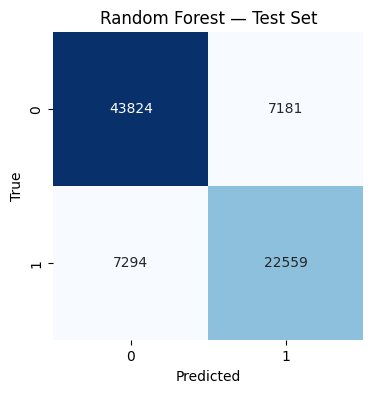

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Random Forest — Test Set')
plt.show()


## 9. Deep Learning Approach — RNN / LSTM

Instead of two separate branches (a "Siamese" network), we take the simpler path: **concatenate**
question1 and question2 into a single string, tokenize the combined text, and let a recurrent
layer (RNN, then LSTM) learn to spot duplicate patterns directly from that combined sequence.
This is easier to reason about, at some cost to modeling power vs. a Siamese architecture.


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


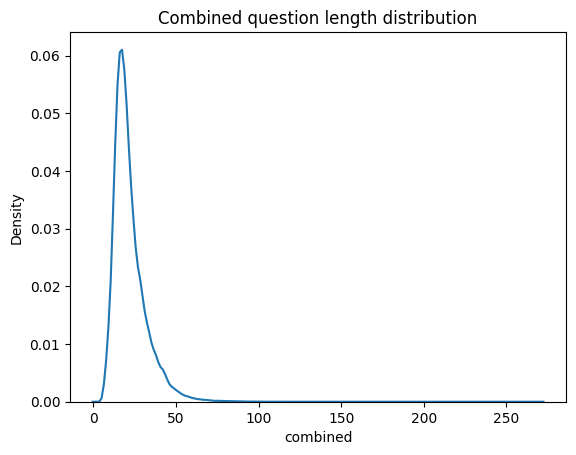

95th percentile length: 41


In [ ]:
train_df["combined"] = train_df["question1"] + " " + train_df["question2"]
test_df["combined"] = test_df["question1"] + " " + test_df["question2"]

lengths = train_df["combined"].apply(lambda s: len(s.split()))
sns.kdeplot(lengths)
plt.title("Combined question length distribution")
plt.show()
print("95th percentile length:", int(lengths.quantile(0.95)))


In [ ]:
MAX_LEN = 40  # covers the vast majority of combined question pairs, adjust from the plot above

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["combined"])  # fit ONLY on train text, same rule as everything else

train_seq = tokenizer.texts_to_sequences(train_df["combined"])
test_seq = tokenizer.texts_to_sequences(test_df["combined"])

train_seq = pad_sequences(train_seq, padding="post", maxlen=MAX_LEN)
test_seq = pad_sequences(test_seq, padding="post", maxlen=MAX_LEN)

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)
print(train_seq.shape, test_seq.shape)


Vocab size: 86154
(323429, 40) (80858, 40)


### Oversample the training sequences only

Same rule as before — the resampling happens strictly after the split, and only touches
training data. `RandomOverSampler` (rather than SMOTE) is used here since these are integer
token-ID sequences, not continuous vectors — SMOTE's interpolation doesn't make sense for
categorical token IDs, but duplicating minority-class rows does.


In [ ]:
ros = RandomOverSampler(random_state=42)
train_seq_res, y_train_res_dl = ros.fit_resample(train_seq, train_df["is_duplicate"])

print("Before:", train_seq.shape, " After:", train_seq_res.shape)


Before: (323429, 40)  After: (408038, 40)


### 9a. SimpleRNN

In [ ]:
from tensorflow.keras import Input

rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=32),
    SimpleRNN(32),
    Dense(1, activation="sigmoid")
])
rnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 32)         │     2,756,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,759,041 (10.52 MB)

 Trainable params: 2,759,041 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

rnn_history = rnn_model.fit(
    train_seq_res, y_train_res_dl,
    epochs=15,
    batch_size=512,
    validation_split=0.1,   # carved out of TRAIN only, test set stays untouched
    callbacks=[early_stop]
)


Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7320 - loss: 0.5360 - val_accuracy: 0.6664 - val_loss: 0.5971
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7979 - loss: 0.4357 - val_accuracy: 0.7114 - val_loss: 0.5367
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8480 - loss: 0.3447 - val_accuracy: 0.8708 - val_loss: 0.3199
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8806 - loss: 0.2801 - val_accuracy: 0.8337 - val_loss: 0.3754
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9028 - loss: 0.2350 - val_accuracy: 0.9444 - val_loss: 0.1891
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9182 - loss: 0.2016 - val_accuracy: 0.9394 - val_loss: 0.1738
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9303 - loss: 0.1748 - val_accuracy: 0.9498 - val_loss: 0.1567
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9386 - loss: 0.1546 - val_accuracy: 

In [ ]:
y_pred_prob = rnn_model.predict(test_seq)
y_pred_rnn = (y_pred_prob > 0.5).astype(int).flatten()

print("=== SimpleRNN — real held-out test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rnn))
print("F1:", f1_score(y_test, y_pred_rnn))
print(classification_report(y_test, y_pred_rnn))


2527/2527 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
=== SimpleRNN — real held-out test set ===
Accuracy: 0.7442924633307774
F1: 0.6647425087559995
              precision    recall  f1-score   support

           0       0.81      0.78      0.79     51005
           1       0.64      0.69      0.66     29853

    accuracy                           0.74     80858
   macro avg       0.73      0.73      0.73     80858
weighted avg       0.75      0.74      0.75     80858



### 9b. Bidirectional LSTM

A step up from SimpleRNN: LSTM handles longer-range dependencies better (SimpleRNN tends to
"forget" earlier words in longer sequences), and going Bidirectional lets the model read the
combined question pair both forwards and backwards.


In [ ]:
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=32, input_length=MAX_LEN),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
lstm_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 32)         │     2,756,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,773,633 (10.58 MB)

 Trainable params: 2,773,633 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

In [ ]:
lstm_history = lstm_model.fit(
    train_seq_res, y_train_res_dl,
    epochs=15,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7270 - loss: 0.5355 - val_accuracy: 0.7160 - val_loss: 0.5385
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7790 - loss: 0.4618 - val_accuracy: 0.8032 - val_loss: 0.4419


In [ ]:
print("Epochs actually run:", len(rnn_history.epoch))
print("Stopped early:", rnn_model.stop_training)

Epochs actually run: 9
Stopped early: True


In [ ]:
y_pred_prob = lstm_model.predict(test_seq)
y_pred_lstm = (y_pred_prob > 0.5).astype(int).flatten()

print("=== Bidirectional LSTM — real held-out test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("F1:", f1_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))


2527/2527 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
=== Bidirectional LSTM — real held-out test set ===
Accuracy: 0.7528012070543422
F1: 0.6728962785978464
              precision    recall  f1-score   support

           0       0.81      0.79      0.80     51005
           1       0.66      0.69      0.67     29853

    accuracy                           0.75     80858
   macro avg       0.74      0.74      0.74     80858
weighted avg       0.76      0.75      0.75     80858



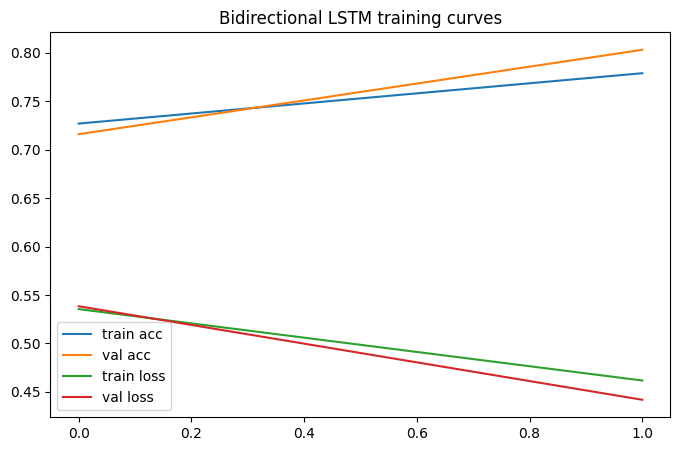

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['accuracy'], label='train acc')
plt.plot(lstm_history.history['val_accuracy'], label='val acc')
plt.plot(lstm_history.history['loss'], label='train loss')
plt.plot(lstm_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Bidirectional LSTM training curves")
plt.show()


In [ ]:
print("Epochs actually run:", len(lstm_history.epoch))
print("Stopped early:", lstm_model.stop_training)

Epochs actually run: 2
Stopped early: True


In [ ]:
lstm_early_stop2 = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

lstm_history2 = lstm_model.fit(
    train_seq_res, y_train_res_dl,
    epochs=15,
    batch_size=512,
    validation_split=0.1,
    callbacks=[lstm_early_stop2]
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7794 - loss: 0.4602 - val_accuracy: 0.7038 - val_loss: 0.5716
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8070 - loss: 0.4109 - val_accuracy: 0.8223 - val_loss: 0.4141
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8322 - loss: 0.3641 - val_accuracy: 0.8528 - val_loss: 0.3700
Epoch 4/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8513 - loss: 0.3273 - val_accuracy: 0.8690 - val_loss: 0.3311
Epoch 5/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8661 - loss: 0.2974 - val_accuracy: 0.9156 - val_loss: 0.2796
Epoch 6/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8788 - loss: 0.2718 - val_accuracy: 0.9218 - val_loss: 0.2544
Epoch 7/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8894 - loss: 0.2495 - val_accuracy: 0.9456 - val_loss: 0.1996
Epoch 8/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8984 - loss: 0.2307 - val_ac

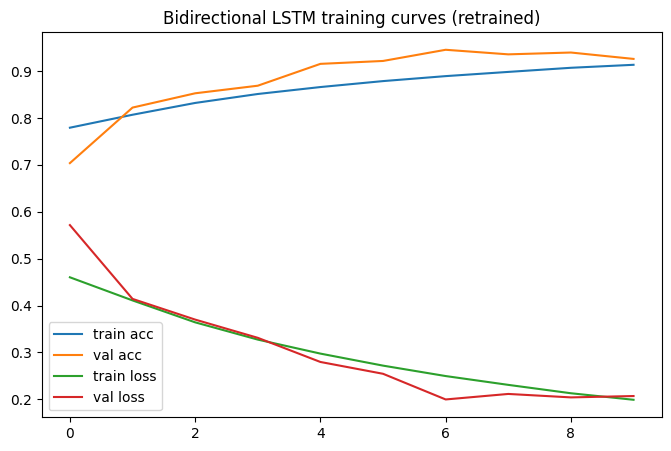

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history2.history['accuracy'], label='train acc')
plt.plot(lstm_history2.history['val_accuracy'], label='val acc')
plt.plot(lstm_history2.history['loss'], label='train loss')
plt.plot(lstm_history2.history['val_loss'], label='val loss')
plt.legend()
plt.title("Bidirectional LSTM training curves (retrained)")
plt.show()

In [ ]:
y_pred_prob2 = lstm_model.predict(test_seq)
y_pred_lstm2 = (y_pred_prob2 > 0.5).astype(int).flatten()

print("=== Bidirectional LSTM (retrained) — real held-out test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm2))
print("F1:", f1_score(y_test, y_pred_lstm2))
print(classification_report(y_test, y_pred_lstm2))

2527/2527 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
=== Bidirectional LSTM (retrained) — real held-out test set ===
Accuracy: 0.7552004749066265
F1: 0.7027481603844421
              precision    recall  f1-score   support

           0       0.85      0.74      0.79     51005
           1       0.64      0.78      0.70     29853

    accuracy                           0.76     80858
   macro avg       0.75      0.76      0.75     80858
weighted avg       0.77      0.76      0.76     80858



## 10. Compare All Models

| Model                        | Accuracy | F1 (duplicate) |
|-------------------------------|----------|------------------|
| Random Forest (Word2Vec+feat) | ?        | ?                |
| SimpleRNN                     | ?        | ?                |
| Bidirectional LSTM             | ?        | ?                |

Fill this in from the outputs above. Since every model here was evaluated on the **same
untouched test set**, this comparison is fair and trustworthy — unlike the reference notebook,
where oversampling before splitting could let the model see near-duplicates of test rows during
training.


## 11. Inference on New Question Pairs

A small helper function to test the trained LSTM model on any two questions you type in.


In [ ]:
def predict_duplicate(q1, q2, model=lstm_model, tokenizer=tokenizer, max_len=MAX_LEN):
    combined = [q1 + " " + q2]
    seq = tokenizer.texts_to_sequences(combined)
    seq = pad_sequences(seq, padding="post", maxlen=max_len)
    prob = model.predict(seq, verbose=0)[0][0]
    label = "DUPLICATE" if prob >= 0.5 else "DIFFERENT"
    return label, float(prob)

# Try it out
predict_duplicate(
    "What are some common examples of solid matter?",
    "What are the most common examples of solid matter?"
)


('DUPLICATE', 0.8819615840911865)

In [ ]:
# Run on a random sample of real question pairs to eyeball predictions
sample = test_df.sample(10, random_state=1).reset_index(drop=True)

results = []
for i in range(len(sample)):
    label, prob = predict_duplicate(sample["question1"][i], sample["question2"][i])
    results.append(label)

sample["Predicted"] = results
sample["Actual"] = sample["is_duplicate"].map({0: "DIFFERENT", 1: "DUPLICATE"})
sample[["question1", "question2", "Actual", "Predicted"]]


,question1,question2,Actual,Predicted
0,Where can I buy very good quality and reliable...,Where can I get some good books for the role o...,DIFFERENT,DIFFERENT
1,Cosmetology: What are the best private label c...,China cosmetic companies?,DUPLICATE,DUPLICATE
2,What is an essay?,What is an essay on water?,DIFFERENT,DUPLICATE
3,When will episode 278 of fairy tail come out?,When will Fairy Tail episodes 240-265 be dubbed?,DIFFERENT,DIFFERENT
4,How do I get certificate in mechanical enginee...,How do I get certification in mechanical engin...,DUPLICATE,DUPLICATE
5,How do you share a video from Facebook to What...,How can I change the thumbnail image of the vi...,DIFFERENT,DIFFERENT
6,What are some of the best films based on DC co...,Who is the best DC comics villain?,DIFFERENT,DUPLICATE
7,What are the strongest majors in terms of job ...,What are the strongest majors in terms of job ...,DIFFERENT,DIFFERENT
8,It's possible to search questions inside a topic?,How can we search questions using multiple top...,DUPLICATE,DUPLICATE
9,What are the good books for CAT preparation?,What are the recommended books/materials for t...,DUPLICATE,DUPLICATE


## Summary

- Cleaned text → Word2Vec (mean-pooled) + simple length/overlap features → Random Forest baseline
- Concatenated question pairs → tokenized → SimpleRNN, then Bidirectional LSTM
- All oversampling done **after** the train/test split, and only on the training set — the test
  set stays untouched and realistic, so the reported metrics are trustworthy
